# Phase 5 & 6 — Data Validation & EDA

We load our reproducible 100-image subset, validate it rigorously against the requirements, and explore its characteristics before training.

In [1]:
# ── Step 0: Imports ───────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import medmnist
from medmnist import INFO

DATA_CACHE_DIR = '../data/'
MANIFEST_PATH  = '../data/processed/subset_manifest.csv'

In [2]:
# ── Step 1: Load Data & Manifest ──────────────────────────────────────────────
print('Loading manifest...')
manifest = pd.read_csv(MANIFEST_PATH)

print('Loading raw PneumoniaMNIST into memory...')
info = INFO['pneumoniamnist']
DataClass = getattr(medmnist, info['python_class'])
dataset = DataClass(split='train', download=False, root=DATA_CACHE_DIR)

all_images = dataset.imgs
all_labels = dataset.labels.squeeze()

subset_indices = manifest['original_index'].values
X_tiny = all_images[subset_indices]
y_tiny = all_labels[subset_indices]

print(f'\nSubset loaded into X_tiny {X_tiny.shape} and y_tiny {y_tiny.shape}')

Loading manifest...
Loading raw PneumoniaMNIST into memory...

Subset loaded into X_tiny (100, 28, 28) and y_tiny (100,)


In [3]:
# ── Step 2: Phase 5 - Data Validation (Fail Loudly) ───────────────────────────
print('Running strict validations...')

assert X_tiny.shape == (100, 28, 28), f"Shape mismatch! Got {X_tiny.shape}"
assert len(y_tiny) == 100,            f"Label count mismatch! Got {len(y_tiny)}"

assert not np.isnan(X_tiny).any(),    "Found missing pixels (NaN)!"
assert not np.isnan(y_tiny).any(),    "Found missing labels (NaN)!"

valid_labels = set([0, 1])
actual_labels = set(np.unique(y_tiny))
assert actual_labels.issubset(valid_labels), f"Invalid labels found! Got {actual_labels}"

class_counts = dict(zip(*np.unique(y_tiny, return_counts=True)))
assert class_counts.get(0, 0) == 50,  f"Class 0 count not 50. Got {class_counts.get(0,0)}"
assert class_counts.get(1, 0) == 50,  f"Class 1 count not 50. Got {class_counts.get(1,0)}"

print('\n✅ Validation Passed!\nTotal: 100\nValid: 100\nInvalid: 0\nClass 0: 50\nClass 1: 50')

Running strict validations...

✅ Validation Passed!
Total: 100
Valid: 100
Invalid: 0
Class 0: 50
Class 1: 50


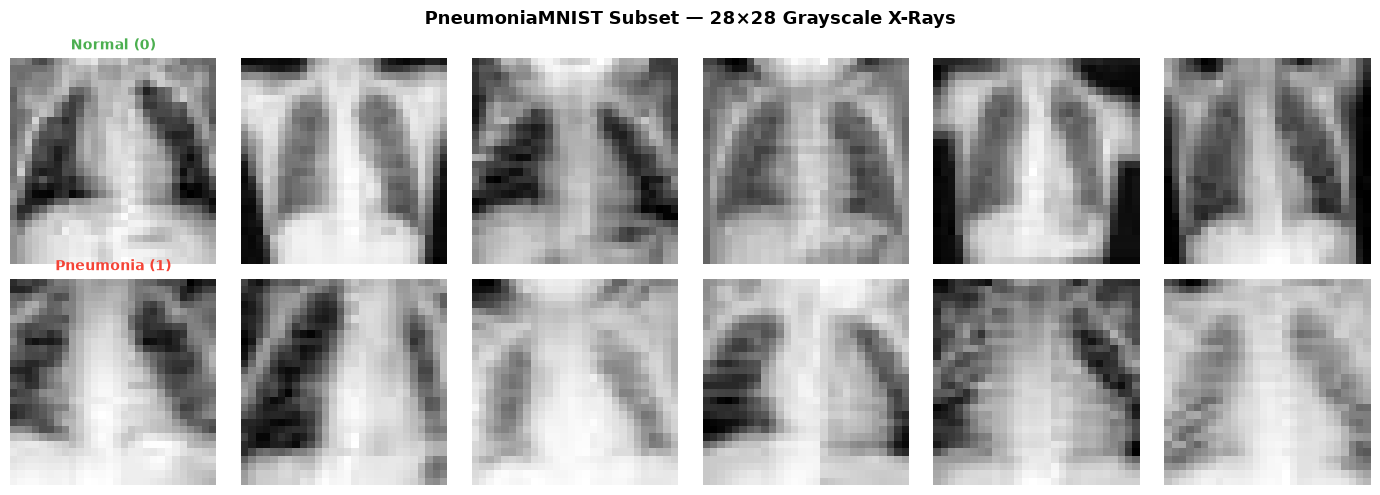

In [4]:
# ── Step 3: Phase 6 - EDA Visual Samples ──────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('PneumoniaMNIST Subset — 28×28 Grayscale X-Rays', fontsize=13, fontweight='bold')

label_names = {0: 'Normal', 1: 'Pneumonia'}
colors = {0: '#4CAF50', 1: '#F44336'}

for row, cls in enumerate([0, 1]):
    cls_indices = np.where(y_tiny == cls)[0][:6]
    for col, idx in enumerate(cls_indices):
        ax = axes[row, col]
        ax.imshow(X_tiny[idx], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f'{label_names[cls]} ({cls})', fontsize=10, fontweight='bold', color=colors[cls])

plt.tight_layout()
plt.show()

=== Pixel Statistics (Raw 0-255) ===
Min   : 0
Max   : 255
Mean  : 146.70
Std   : 46.05


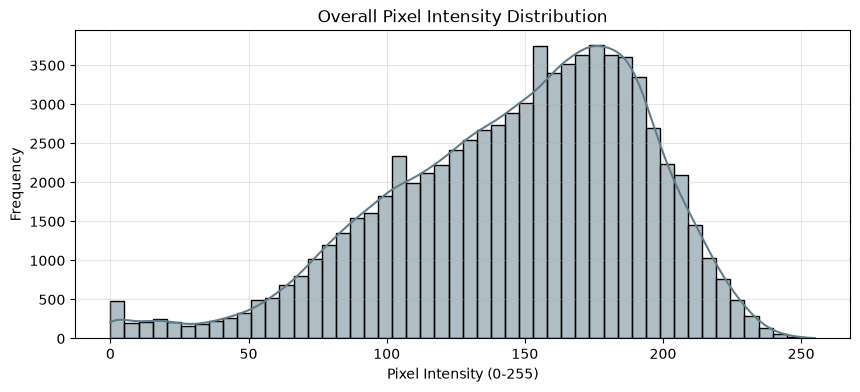

In [5]:
# ── Step 4: EDA Pixel Statistics ──────────────────────────────────────────────
print('=== Pixel Statistics (Raw 0-255) ===')
print(f'Min   : {X_tiny.min()}')
print(f'Max   : {X_tiny.max()}')
print(f'Mean  : {X_tiny.mean():.2f}')
print(f'Std   : {X_tiny.std():.2f}')

plt.figure(figsize=(10, 4))
sns.histplot(X_tiny.flatten(), bins=50, color='#607D8B', kde=True)
plt.title('Overall Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/vh/355cqfcs3zg2b7lwzkzk50w80000gn/T/ipykernel_30421/249113119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_tiny, palette=[colors[0], colors[1]])


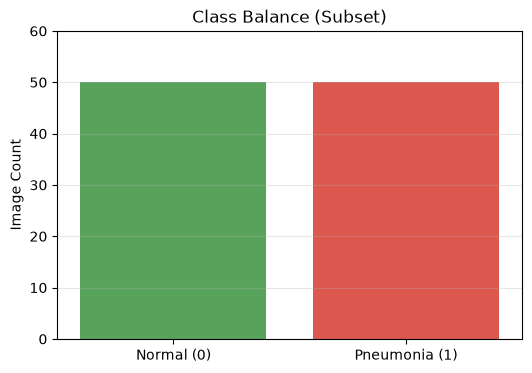

In [6]:
# ── Step 5: EDA Class Balance Chart ───────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.countplot(x=y_tiny, palette=[colors[0], colors[1]])
plt.title('Class Balance (Subset)')
plt.xticks([0, 1], ['Normal (0)', 'Pneumonia (1)'])
plt.ylabel('Image Count')
plt.ylim(0, 60)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Findings

- **Is the class distribution balanced?** Yes, exactly 50 Normal and 50 Pneumonia samples.
- **Are images visually similar?** Yes, all are standardized 28x28 grayscale chest X-rays. Ribcages and lung fields are visible, but heavily downsampled.
- **Are there obvious artifacts?** No severe artifacts found, though the 28x28 resolution removes fine detail.
- **Are there suspicious duplicates?** Validations passed with no index duplicates.
- **Is the dataset too small for strong conclusions?** Yes. 100 images is extremely small for deep learning and will result in high variance. We cannot claim clinical performance from this experiment.